<a href="https://colab.research.google.com/github/saicharann4518-ai/Aiml-Training-IIIT-charan/blob/main/Aiml_Lab_1_Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting features from data
Module 1, Lab 1


In [ ]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [ ]:
# ---------- English Topics ----------
topic1 = 'Aircraft'
topic2 = 'Bus (vehicle)'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content


# ----- Aeroplane Article -----
print(topic1, "Article:")
print(eng1[:100])

print("Length of article:", len(eng1))

print("Does the word 'Aircraft' appear in article?", "Aircraft" in eng1)

text1 = eng1.lower()
print("Lowercase text sample:")
print(text1[:100])

print("\n")


# ----- Bus Article -----
print(topic2, "Article:")
print(eng2[:100])

print("Length of article:", len(eng2))

print("Does the word 'Bus' appear in article?", "Bus" in eng2)

text2 = eng2.lower()
print("Lowercase text sample:")
print(text2[:100])

print("\n")


# ---------- Telugu Topics ----------
topic1 = 'విమానము'
topic2 = 'బస్సు'

wikipedia.set_lang('te')

tel1 = wikipedia.page(wikipedia.search(topic1)[0]).content
tel2 = wikipedia.page(wikipedia.search(topic2)[0]).content


print(topic1, "Article:")
print(tel1[:120])

print("\n")

print(topic2, "Article:")
print(tel2[:120])

Aircraft Article:
An aircraft is a vehicle that is able to fly by gaining support from the air. It counters the force 
Length of article: 29673
Does the word 'Aircraft' appear in article? True
Lowercase text sample:
an aircraft is a vehicle that is able to fly by gaining support from the air. it counters the force 


Bus (vehicle) Article:
A bus (contracted from omnibus, with variants multibus, motorbus, autobus, etc.) is a motor vehicle 
Length of article: 31084
Does the word 'Bus' appear in article? True
Lowercase text sample:
a bus (contracted from omnibus, with variants multibus, motorbus, autobus, etc.) is a motor vehicle 


విమానము Article:
విమానం (ఆంగ్లం Aeroplane) అనేది సాధారణ వాడుకలో గాలిలో ప్రయాణించడానికి వీలుగా తయారుచేయబడిన వాహనము. వీటినే ఎయిర్‌ప్లేన్‌లు


బస్సు Article:
బస్సు (బహువచనం: బస్సులు). 'బస్' అనే పదానికి మూలం లాటిన్ పదం 'ఆమ్నిబస్' అనగా "అందరికీ". రోడ్డుపై నడిచే ఒక పెద్ద వాహనం, పె


We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution

In [ ]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z\u0C00-\u0C7F]+', '', text)  # keep English + Telugu characters
  return text

In [ ]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
tel1 = cleanup(tel1)
tel2 = cleanup(tel2)

print(eng1)
print(eng2)
print(tel1)
print(tel2)

...
విమానంఆంగ్లంaeroplaneఅనేదిసాధారణవాడుకలోగాలిలోప్రయాణించడానికివీలుగాతయారుచేయబడినవాహనమువీటినేఎయిర్ప్లేన్లుఅనిఉత్తరఅమెరికాలోయుఎస్కెనడాఏరోప్లేన్లుఅనికామన్వెల్త్దేశాల్లోఒకకెనడాతప్పఐర్లాండ్లోవ్యవహరిస్తారుఈపదాలుగ్రీకుభాషనుండిఆవిర్భవించాయిగ్రీక్భాషలోఏరాస్అనగాగాలిఅనిఅర్థంలోరైట్సోదరులుఏరోప్లేన్అన్నపదాన్నిఒకరెక్కనువివరించడానికిమాత్రమేవాడారుకానిఅదిపూర్తివిమానానికిపేరుగావాడుకలోకివచ్చిందివిమానాన్నిసాంకేతికపరిభాషలోఫిక్స్డ్వింగ్ఎయిర్క్రాఫ్ట్fixedwingaircraftఅనిఅంటారుఅంటేస్థిరంగాకదలకుండారెక్కలుఉండేవిమానంఇతరవిమానాలతోరోటరీవింగ్ఏర్క్రాఫ్ట్లేదాఆర్నిథాప్టర్స్వీటినివేరుచేయడానికిఅనువుగాఈపదాన్నివాడతారుఫిక్స్డ్వింగ్ఎయిర్క్రాఫ్ట్గాలికంటేబరువైనదైఉండడంతోపాటురెక్కలుఎగరడానికికావాలసినశక్తినివిమానానికిఇవ్వలేవుపనిచేసేసూత్రంగాలిలోప్రయాణించేఏవస్తువుమీదైనాప్రధానంగానాలుగుబలాలుపనిచేస్తాయనిశాస్త్రజ్ఞుడుజార్జికేలీసూత్రీకరించాడుఅవిపైనప్రయాణిస్తుండేవస్తువునునిరంతరంకిందకులాగుతుండేగురుత్వాకర్షణశక్తిఅదేదానిబరువుభౌతికశాస్త్రంలోదీనినేభారముఅనికూడఅంటారుభారముద్రవ్యరాశిగురుత్వాకర్షణశక్తిwmgwభారముmద్రవ్యరాశిgగురుత్వాకర్షణశక్తిఈబరువుకు

Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [ ]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

Let us compare the histograms of English pages and telugu pages. Can you spot a difference?

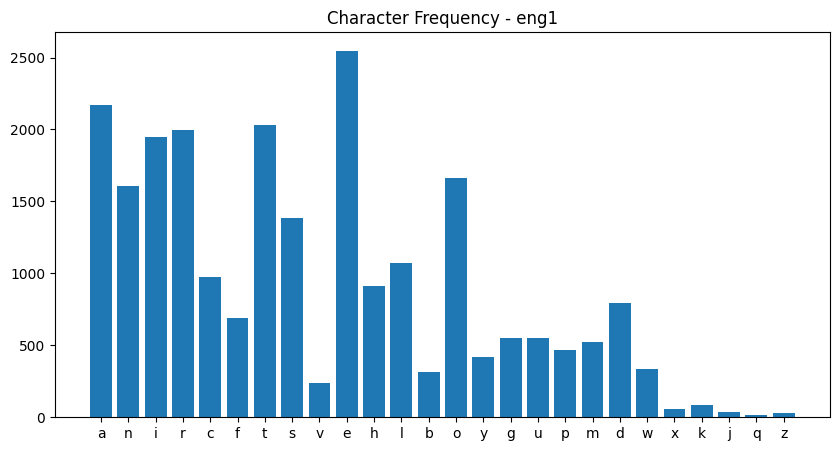

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

freq_eng1 = Counter(eng1)

plt.figure(figsize=(10,5))
plt.bar(freq_eng1.keys(), freq_eng1.values())
plt.title("Character Frequency - eng1")
plt.show()

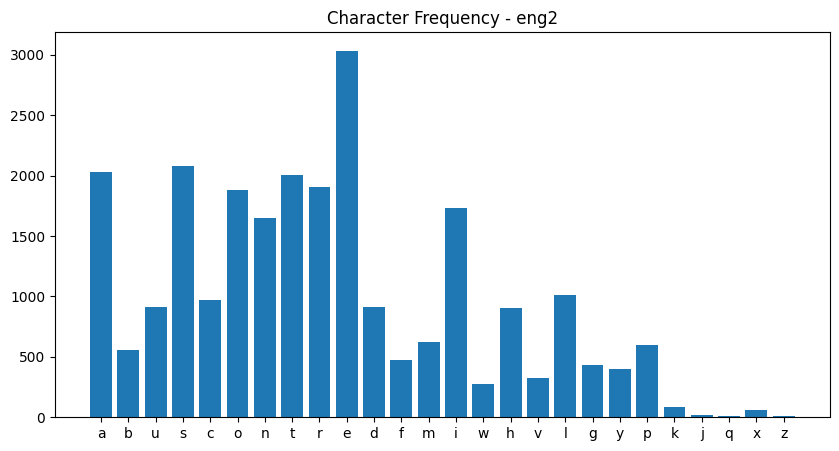

In [ ]:
freq_eng2 = Counter(eng2)

plt.figure(figsize=(10,5))
plt.bar(freq_eng2.keys(), freq_eng2.values())
plt.title("Character Frequency - eng2")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 3125 (\N{TELUGU LETTER VA}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Matplotlib currently does not support Telugu natively.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 3135 (\N{TELUGU VOWEL SIGN I}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 3118 (\N{TELUGU LETTER MA}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 3134 (\N{TELUGU VOWEL SIGN AA}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 3112 (\N{TELUGU LETTER NA}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: User

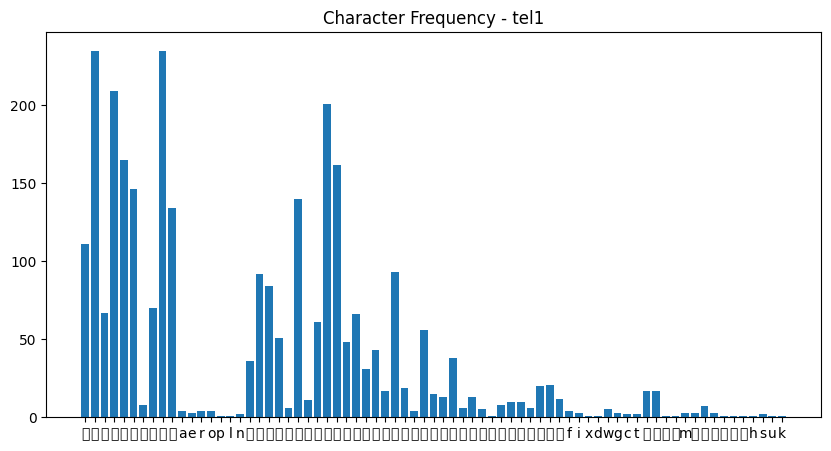

In [ ]:
freq_tel1 = Counter(tel1)

plt.figure(figsize=(10,5))
plt.bar(freq_tel1.keys(), freq_tel1.values())
plt.title("Character Frequency - tel1")
plt.show()

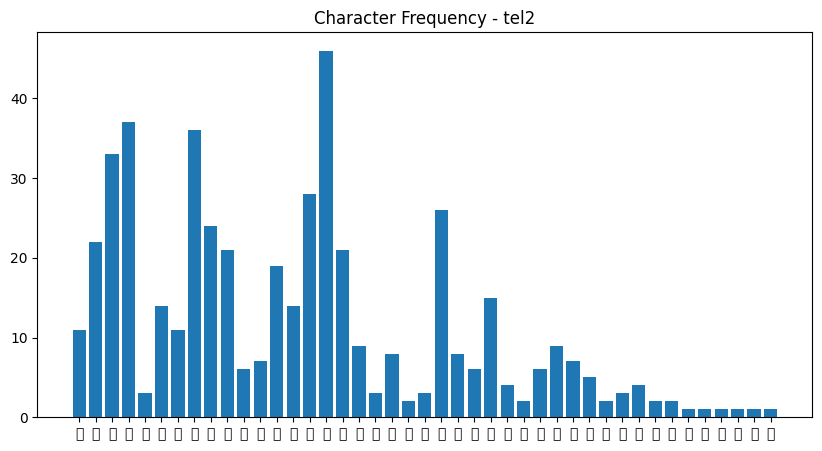

In [ ]:
freq_tel2 = Counter(tel2)

plt.figure(figsize=(10,5))
plt.bar(freq_tel2.keys(), freq_tel2.values())
plt.title("Character Frequency - tel2")
plt.show()

We can see that the unigrams for telugu and English are very similar. So this is not a good feature if we want to distinguish between English and telugu. Let us look at bigrams.

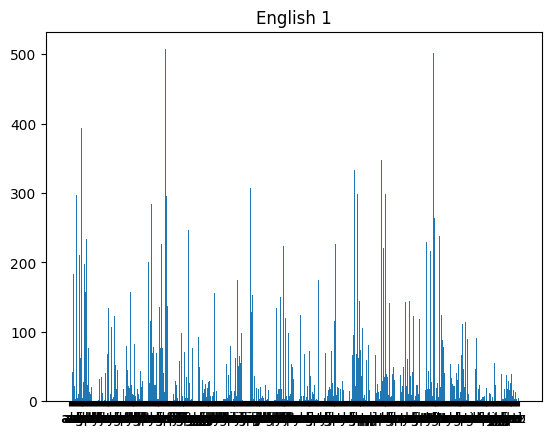

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2))
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

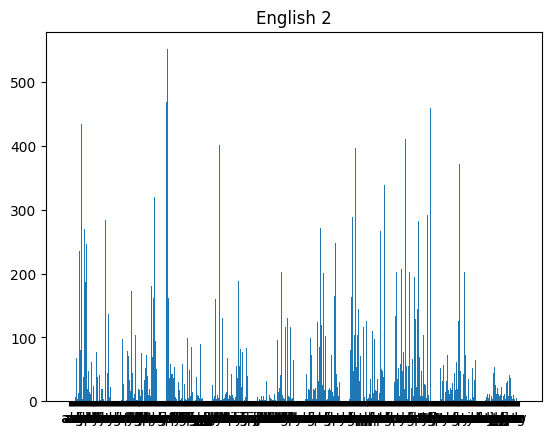

In [ ]:
bigram_eng2 = Counter(ngrams(eng2,2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

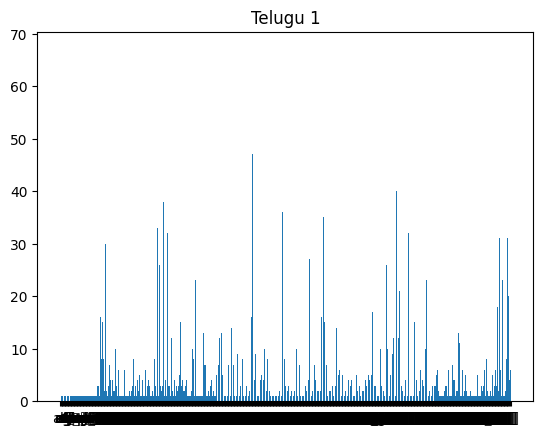

In [ ]:
bigram_tel1 = Counter(ngrams(tel1,2))
plothistogram(bigram_tel1)
plt.title('Telugu 1')
plt.show()

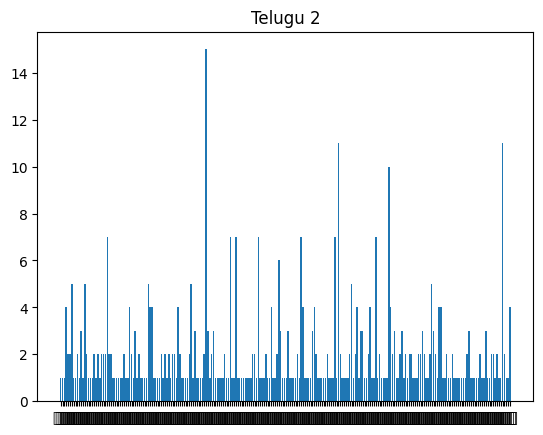

In [ ]:
bigram_tel2 = Counter(ngrams(tel2,2))
plothistogram(bigram_tel2)
plt.title('Telugu 2')
plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.


In [ ]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

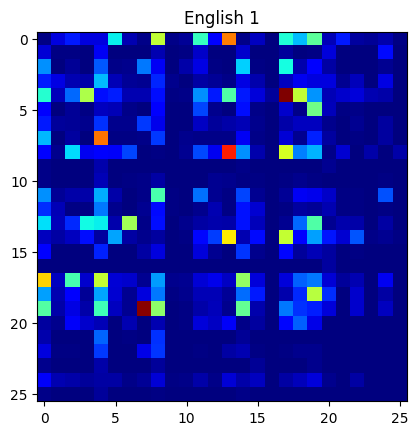

In [ ]:
bigram_eng1 = Counter(ngrams(eng1,2))
plotbihistogram(bigram_eng1)
plt.title("English 1")
plt.show()

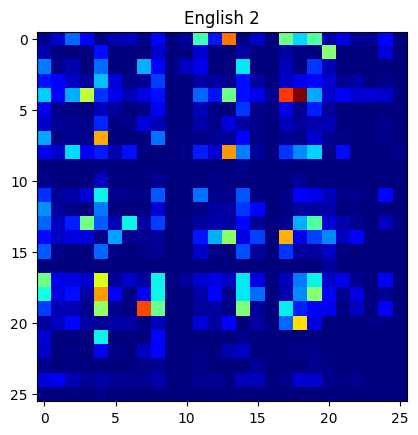

In [ ]:
bigram_eng2 = Counter(ngrams(eng2,2))
plotbihistogram(bigram_eng2)
plt.title("English 2")
plt.show()

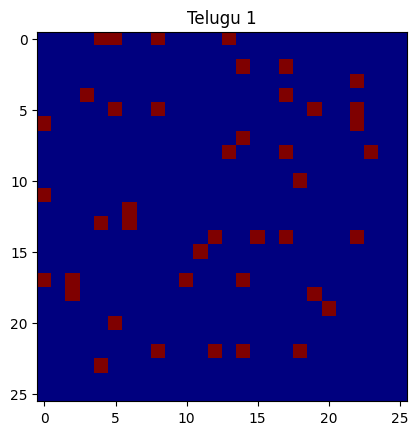

In [ ]:
bigram_tel1 = Counter(ngrams(tel1,2))
plotbihistogram(bigram_tel1)
plt.title("Telugu 1")
plt.show()

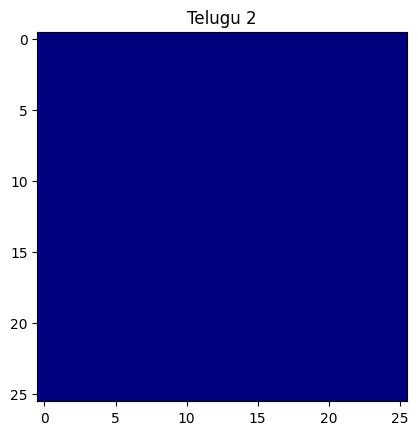

In [ ]:
bigram_tel2 = Counter(ngrams(tel2,2))
plotbihistogram(bigram_tel2)
plt.title("Telugu 2")
plt.show()

Let us look at the top 10 ngrams for each text.

In [ ]:
from IPython.core.debugger import set_trace

def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

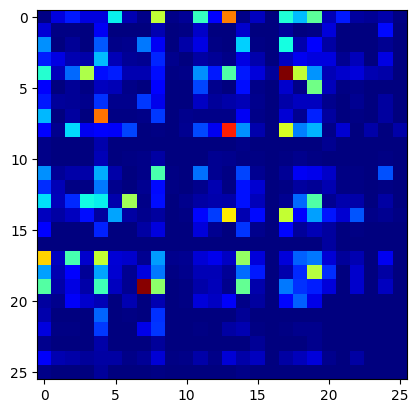

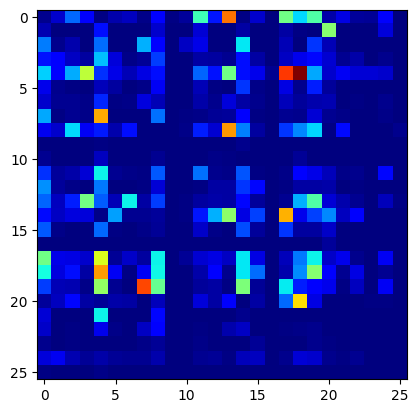

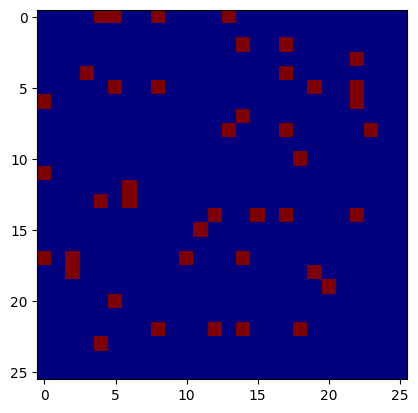

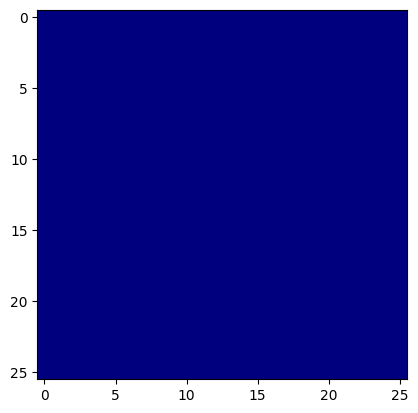

In [ ]:
bieng1 = plotbihistogram(bigram_eng1)
plt.show()

bieng2 = plotbihistogram(bigram_eng2)
plt.show()

bitel1 = plotbihistogram(bigram_tel1)
plt.show()

bitel2 = plotbihistogram(bigram_tel2)
plt.show()

In [ ]:
print('\nEnglish 1:')
ShowTopN(bieng1)

print('\nEnglish 2:')
ShowTopN(bieng2)

print('\nTelugu 1:')
ShowTopN(bitel1)

print('\nTelugu 2:')
ShowTopN(bitel2)


English 1:
('e', 'r') : 507.0
('t', 'h') : 502.0
('i', 'n') : 444.0
('h', 'e') : 400.0
('a', 'n') : 394.0
('r', 'a') : 348.0
('o', 'n') : 333.0
('i', 'r') : 307.0
('r', 'e') : 299.0
('o', 'r') : 298.0

English 2:
('e', 's') : 551.0
('e', 'r') : 469.0
('t', 'h') : 459.0
('a', 'n') : 434.0
('i', 'n') : 413.0
('s', 'e') : 410.0
('h', 'e') : 401.0
('o', 'r') : 397.0
('u', 's') : 372.0
('r', 'e') : 339.0

Telugu 1:
('x', 'e') : 1.0
('w', 'i') : 1.0
('w', 'm') : 1.0
('w', 'o') : 1.0
('w', 's') : 1.0
('t', 'u') : 1.0
('u', 'f') : 1.0
('s', 't') : 1.0
('s', 'c') : 1.0
('r', 'k') : 1.0

Telugu 2:
('z', 'v') : 0.0
('z', 'u') : 0.0
('z', 't') : 0.0
('z', 's') : 0.0
('z', 'r') : 0.0
('z', 'q') : 0.0
('z', 'p') : 0.0
('z', 'o') : 0.0
('z', 'n') : 0.0
('z', 'm') : 0.0


We observe that the bigram patterns for the texts “Aircraft” and “Bus” are quite similar because both texts are written in the same language (English). Therefore, bigram frequencies do not strongly distinguish between topics when the language is the same.

However, bigram frequencies are generally useful for distinguishing between different languages, since each language tends to have characteristic combinations of characters.

Thus, we were able to convert a many-dimensional input (the text) into numerical features such as 26 dimensions for unigrams and 26 × 26 dimensions for bigrams, which can be used as inputs for machine learning models.

A few ways to explore further

Try the same experiment with different languages and observe how the bigram distributions change.

The topics used here are “Aircraft” and “Bus”. Try using very different topics or texts from other sources instead of Wikipedia to see how the distributions vary.

Extend the idea to trigrams or higher n-grams and explore ways to visualize them.

Part 2: Written numbers
We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [ ]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

Extract a subset of the data for our experiment:

In [ ]:
no1 = train_X[train_y==3,:,:]
no0 = train_X[train_y==5,:,:]

Let us visualize a few images here:

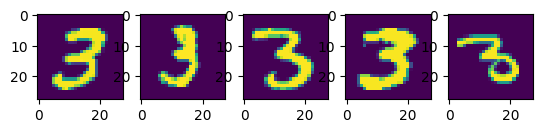

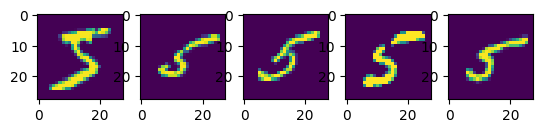

In [ ]:
no3 = train_X[train_y==3,:,:]
no5 = train_X[train_y==5,:,:]

for ii in range(5):
  plt.subplot(1,5,ii+1)
  plt.imshow(no3[ii,:,:])
plt.show()

for ii in range(5):
  plt.subplot(1,5,ii+1)
  plt.imshow(no5[ii,:,:])
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [ ]:
sum3 = np.sum(no3 > 0, (1,2))  # threshold before adding up
sum5 = np.sum(no5 > 0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

(array([  41.,  463.,  987., 1416., 1235.,  774.,  338.,  133.,   29.,
           5.]),
 array([ 63. ,  85.6, 108.2, 130.8, 153.4, 176. , 198.6, 221.2, 243.8,
        266.4, 289. ]),
 <BarContainer object of 10 artists>)

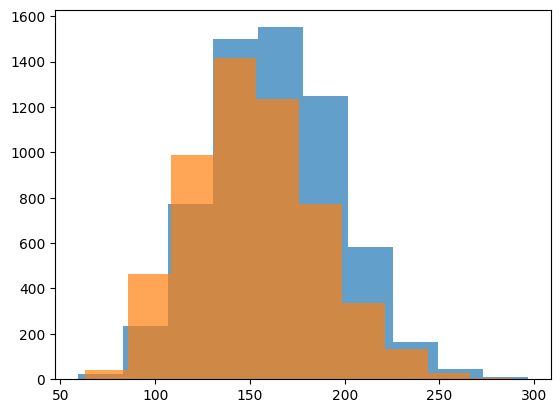

In [ ]:
plt.hist(sum3, alpha=0.7)
plt.hist(sum5, alpha=0.7)

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [ ]:
def cumArray(img):
  img2 = img.copy()
  for ii in range(1, img2.shape[1]):
    img2[ii,:] = img2[ii,:] + img2[ii-1,:]  # for every row, add up all the rows above it.
  img2 = img2>0
  return img2

def getHolePixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  hole = hull & ~ (img>0) # remove the original digit to leave behind the holes
  return hole

Visualize a few:

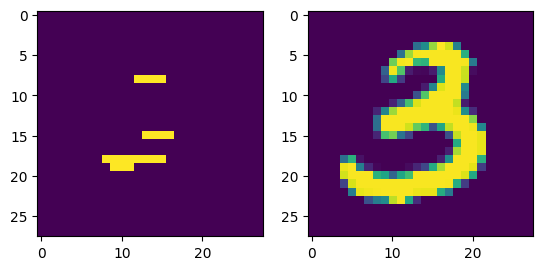

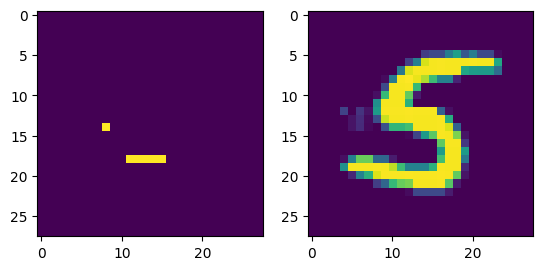

In [ ]:
imgs = [no3[456,:,:], no5[456,:,:]]

for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))

  plt.subplot(1,2,2)
  plt.imshow(img)

  plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

(array([2787., 1306.,  686.,  336.,  130.,   93.,   46.,   19.,   13.,
           5.]),
 array([  0. ,  10.1,  20.2,  30.3,  40.4,  50.5,  60.6,  70.7,  80.8,
         90.9, 101. ]),
 <BarContainer object of 10 artists>)

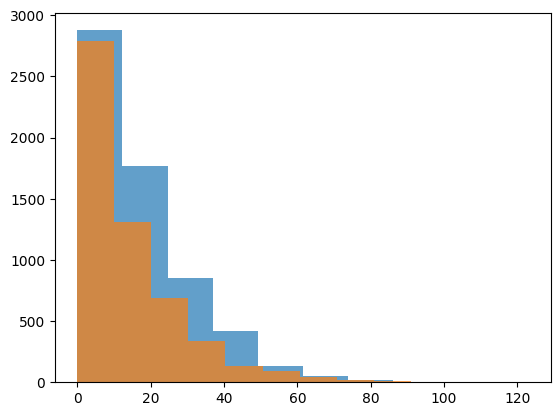

In [ ]:
hole3 = np.array([getHolePixels(i).sum() for i in no3])
hole5 = np.array([getHolePixels(i).sum() for i in no5])

plt.hist(hole3, alpha=0.7)
plt.hist(hole5, alpha=0.7)

This feature works even better to distinguish between three and five.

Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [ ]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

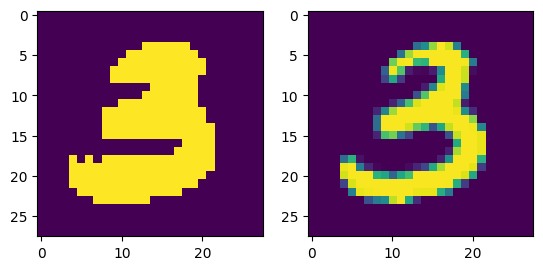

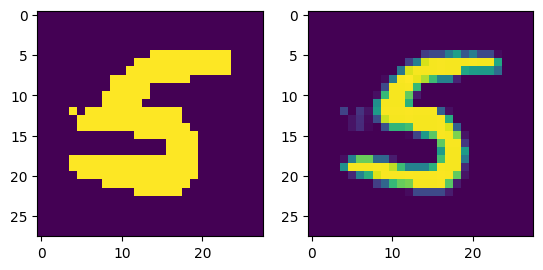

In [ ]:
imgs = [no3[456,:,:], no5[456,:,:]]

for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))

  plt.subplot(1,2,2)
  plt.imshow(img)

  plt.show()

Plotting the number of hull pixels versus the digit:

(array([  50.,  457., 1048., 1249., 1180.,  800.,  427.,  143.,   52.,
          15.]),
 array([ 62. ,  87.4, 112.8, 138.2, 163.6, 189. , 214.4, 239.8, 265.2,
        290.6, 316. ]),
 <BarContainer object of 10 artists>)

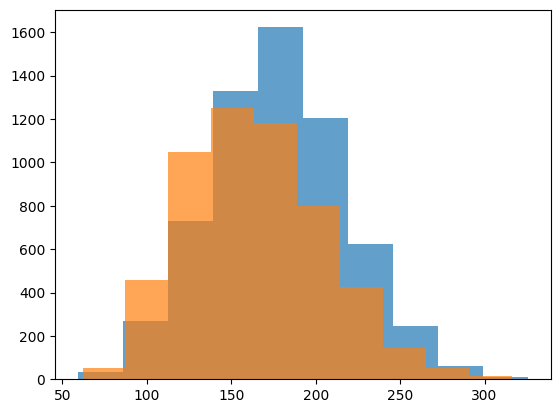

In [ ]:
hull3 = np.array([getHullPixels(i).sum() for i in no3])
hull5 = np.array([getHullPixels(i).sum() for i in no5])

plt.hist(hull3, alpha=0.7)
plt.hist(hull5, alpha=0.7)

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [ ]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

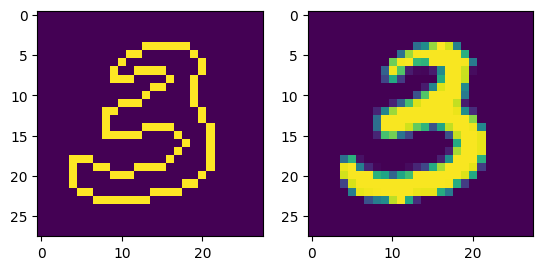

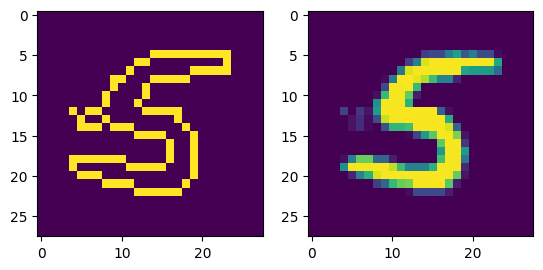

In [ ]:
imgs = [no3[456,:,:], no5[456,:,:]]

for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))

  plt.subplot(1,2,2)
  plt.imshow(img)

  plt.show()

(array([  32.,  237.,  808., 1217., 1274.,  957.,  542.,  250.,   80.,
          24.]),
 array([ 46.,  54.,  62.,  70.,  78.,  86.,  94., 102., 110., 118., 126.]),
 <BarContainer object of 10 artists>)

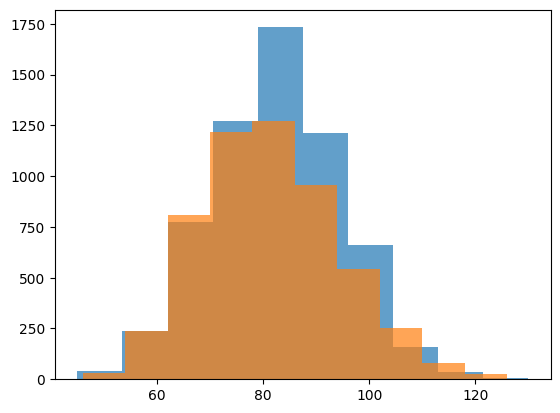

In [ ]:
bound3 = np.array([getBoundaryPixels(i).sum() for i in no3])
bound5 = np.array([getBoundaryPixels(i).sum() for i in no5])

plt.hist(bound3, alpha=0.7)
plt.hist(bound5, alpha=0.7)

What will happen if we plot two features together?

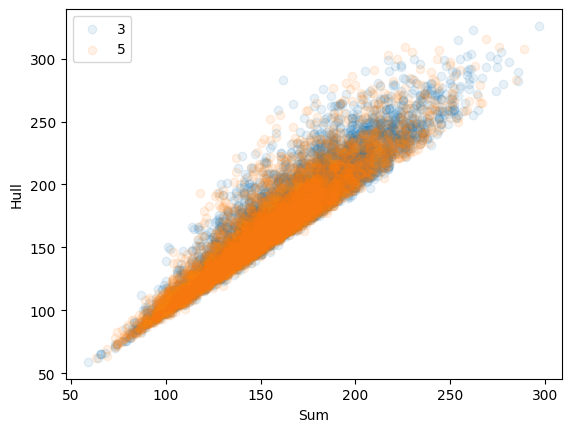

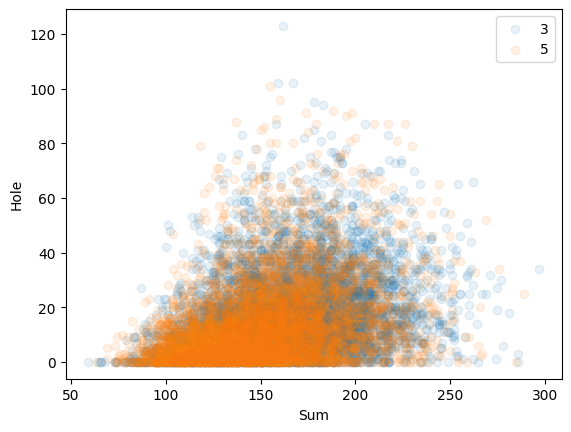

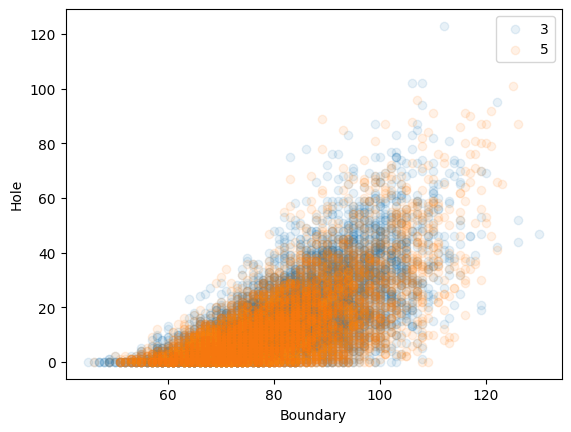

In [ ]:
# Sum and hull
plt.scatter(sum3, hull3, alpha=0.1)
plt.scatter(sum5, hull5, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['3','5'])
plt.show()


# Sum and hole
plt.scatter(sum3, hole3, alpha=0.1)
plt.scatter(sum5, hole5, alpha=0.1)
plt.xlabel('Sum')
plt.ylabel('Hole')
plt.legend(['3','5'])
plt.show()


# Hole and boundary
plt.scatter(bound3, hole3, alpha=0.1)
plt.scatter(bound5, hole5, alpha=0.1)
plt.xlabel('Boundary')
plt.ylabel('Hole')
plt.legend(['3','5'])
plt.show()

Now let us try plotting 3 features together.

In [ ]:
cl3 = ['class 3']*len(sum3)
cl5 = ['class 5']*len(sum5)

df = pd.DataFrame(list(zip(np.concatenate((hole3, hole5)),
                           np.concatenate((sum3, sum5)),
                           np.concatenate((bound3, bound5)),
                           np.concatenate((cl3, cl5)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])

df.head()

fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()